In [10]:
import numpy as np
from scipy import sparse
from scipy.sparse import load_npz
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import sklearn.utils as sku

import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

from scipy.sparse import vstack, load_npz
from sklearn.preprocessing import StandardScaler
import sklearn.metrics as skm
import sklearn.utils as sku

import torch as pt
import torch.nn as nn
import torch.optim as optim

from torch.nn import CrossEntropyLoss
from torch.utils.data import Dataset, DataLoader

import optuna as opt

import Basic_functions as bf

from torchao.sparsity.training import (
    SemiSparseLinear,
    SemiSparseActivationLinear,
    swap_linear_with_semi_sparse_linear,
    swap_semi_sparse_linear_with_linear,
)

# Optional imports
# from torch.nn import L1Loss
# from scipy.special import expit

# --------------------------------------------------------
# FILE IDS TO LOAD
# --------------------------------------------------------

file_ids = [
    "00",
    "01",
    "02",
    "03",
    "04",
    "05",
    "06",
    "07",
    "08",
    "09",
    "10",
    "11",
    "12",
    "13",
    "14",
    "15",
    "16",
    "17",
    "18"
]

# --------------------------------------------------------
# LOAD ARTICLE MATRICES
# --------------------------------------------------------

data_list = [
    load_npz(f"Data_files/data_articles_{fid}.npz")
    for fid in file_ids
]

# --------------------------------------------------------
# LOAD LABEL FILES
# --------------------------------------------------------

label_list = [
    np.genfromtxt(
        f"Data_files/labels_articles_{fid}.txt",
        delimiter="; ",
        dtype=str,
        encoding="latin1"
    )
    for fid in file_ids
]

# --------------------------------------------------------
# CREATE COMBINED DATASET
# --------------------------------------------------------

data_articles_all = sparse.vstack(
    data_list,
    format="csr"
)

labels_articles_all = np.vstack(
    label_list
)

assert data_articles_all.shape[0] == labels_articles_all.shape[0]

print("Initial data shape:", data_articles_all.shape)
print("Initial number of labels:", labels_articles_all.shape[0])

# --------------------------------------------------------
# LABEL COLUMN STRUCTURE
# --------------------------------------------------------
# index = 0 -> date
# index = 1 -> sermon or not
# index = 2 -> article title
# index = 3 -> article topic
# index = 4 -> lix score
# --------------------------------------------------------

# --------------------------------------------------------
# SHUFFLE DATA AND LABELS
# --------------------------------------------------------

data_articles_all, labels_articles_all = sku.shuffle(
    data_articles_all,
    labels_articles_all,
    random_state=5466542
)

# --------------------------------------------------------
# SORT COLUMNS AND KEEP FIRST 251 FEATURES
# --------------------------------------------------------

sort_idx = np.genfromtxt(
    "txt_files/multiclass_sort_idx.txt",
    delimiter="\n",
    dtype=int
)

data_articles_all = data_articles_all[:, sort_idx][:, :3000]

print("Shape after column sorting/top 251:", data_articles_all.shape)

# --------------------------------------------------------
# ADD LIX SCORE AS FIRST COLUMN
# --------------------------------------------------------

lix_scores = labels_articles_all[:, 4].astype(np.float32)

assert data_articles_all.shape[0] == len(lix_scores)

lix_column = sparse.csr_matrix(
    lix_scores.reshape(-1, 1)
)

data_articles_all = sparse.hstack(
    [lix_column, data_articles_all],
    format="csr"
)

# --------------------------------------------------------
# SCALE FEATURES
# --------------------------------------------------------

scaler = StandardScaler(
    with_mean=False
)

data_articles_all = scaler.fit_transform(
    data_articles_all
)

# --------------------------------------------------------
# CONVERT TOPICS TO INTEGER LABELS
# --------------------------------------------------------

topic_labels = labels_articles_all[:, 3]

label_encoder = LabelEncoder()

topic_labels_encoded = label_encoder.fit_transform(
    topic_labels
)

# --------------------------------------------------------
# SPLIT DATA INTO TRAIN, VAL, TEST SETS
# --------------------------------------------------------

data_train, data_train_labels, data_val, data_val_labels, data_test, data_test_labels = bf.train_val_test_split(
    data_articles_all,
    topic_labels_encoded,
    val_size=0.20,
    test_size=0
)

# --------------------------------------------------------
# FINAL OUTPUT
# --------------------------------------------------------

print("\nFinal data shape:", data_articles_all.shape)
print("Final number of labels:", labels_articles_all.shape[0])

print("\nExample feature row:")
print(data_articles_all[0])

print("\nExample label row:")
print(labels_articles_all[0])

Initial data shape: (853077, 27000)
Initial number of labels: 853077
Shape after column sorting/top 251: (853077, 3000)

Final data shape: (853077, 3001)
Final number of labels: 853077

Example feature row:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 452 stored elements and shape (1, 3001)>
  Coords	Values
  (0, 0)	4.481007481307051
  (0, 1340)	0.9192858830610832
  (0, 512)	1.4974049365099833
  (0, 1231)	0.7743898318431803
  (0, 386)	0.6886886906515906
  (0, 424)	0.6371855115364744
  (0, 1451)	1.140590777079802
  (0, 692)	1.8292589415623983
  (0, 389)	0.5565488092878236
  (0, 1068)	0.5727776063507882
  (0, 1037)	0.5544797818538918
  (0, 647)	0.5137874647903341
  (0, 2014)	1.2861879882294096
  (0, 1273)	1.510030026834308
  (0, 109)	0.23791447734770915
  (0, 147)	1.4969517668639885
  (0, 222)	1.8088133649554388
  (0, 253)	1.4481176849559403
  (0, 1794)	3.344110882482408
  (0, 1421)	0.892658253998181
  (0, 183)	1.2376010939087454
  (0, 175)	3.0261584945894953
  (0, 656)	

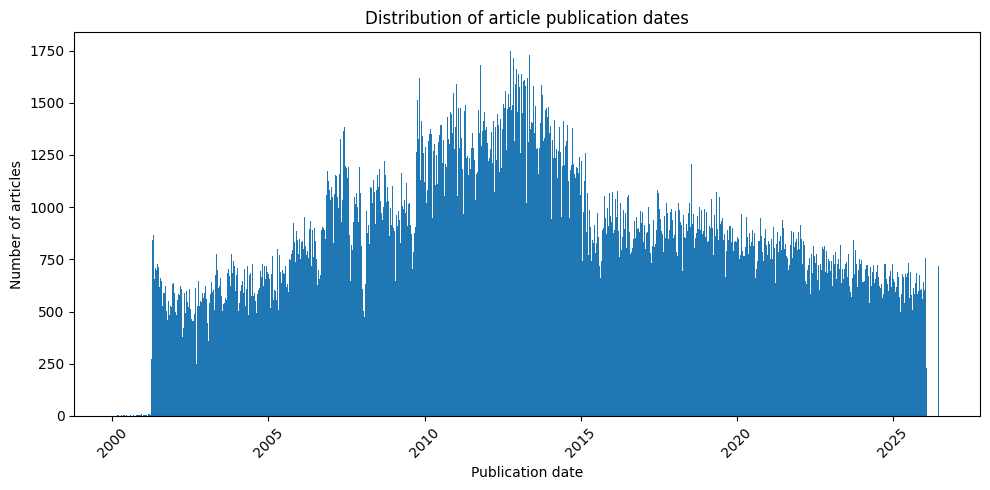

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

years = labels_articles_all[:, 0].astype(float)

plt.figure(figsize=(10, 5))
plt.hist(years, bins=1000)
plt.xlabel("Publication date")
plt.ylabel("Number of articles")
plt.title("Distribution of article publication dates")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

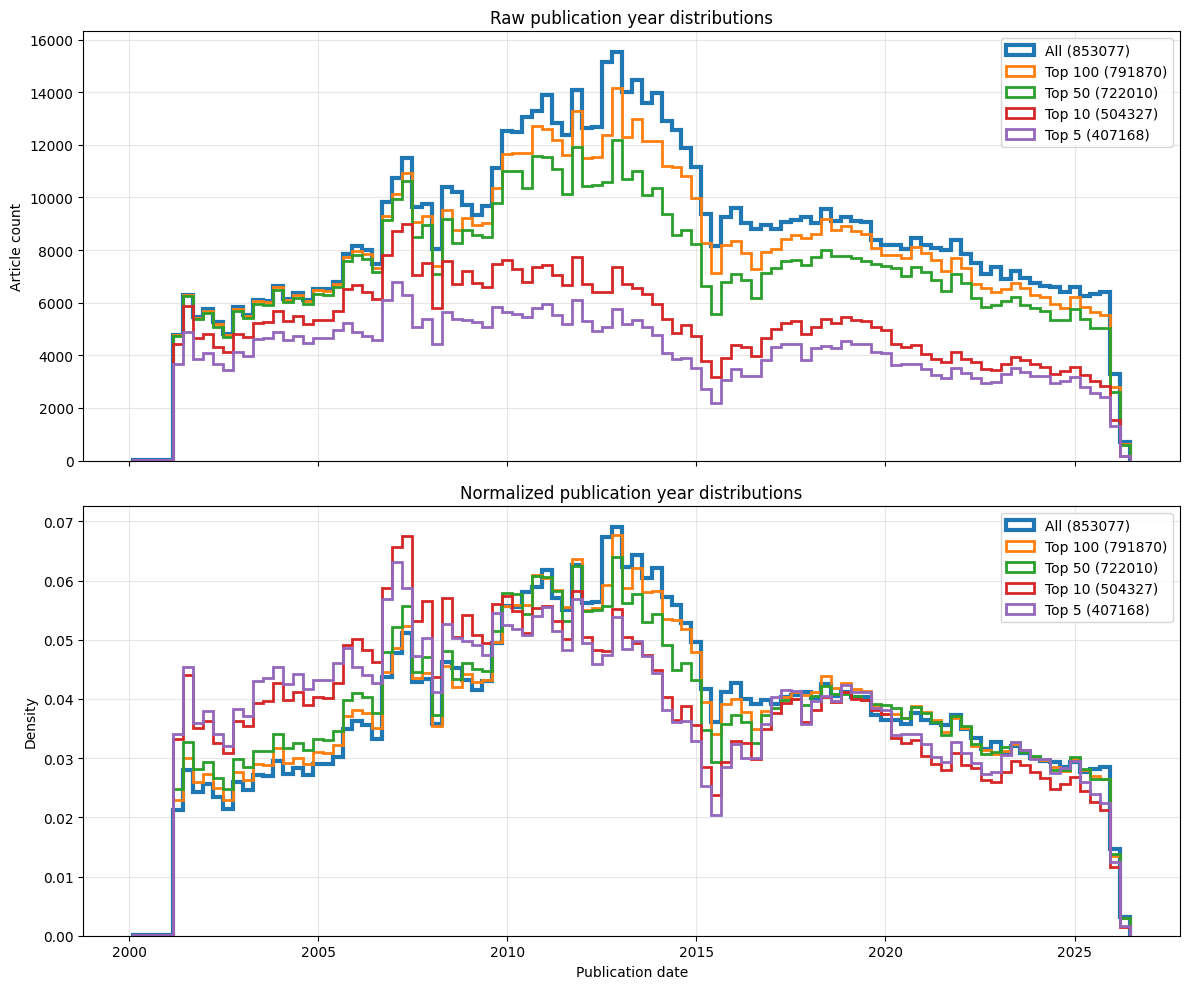

In [25]:
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

years = labels_articles_all[:, 0].astype(float)
topics = labels_articles_all[:, 3]

topic_counts = Counter(topics)

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

for density, ax in zip([False, True], axes):

    # Full dataset
    ax.hist(
        years,
        bins=100,
        density=density,
        histtype="step",
        linewidth=3,
        label=f"All ({len(years)})"
    )

    for n in [100, 50, 10, 5]:

        top_topics = {
            topic
            for topic, count in topic_counts.most_common(n)
        }

        mask = np.isin(topics, list(top_topics))

        ax.hist(
            years[mask],
            bins=100,
            density=density,
            histtype="step",
            linewidth=2,
            label=f"Top {n} ({mask.sum()})"
        )

    ax.legend()
    ax.grid(alpha=0.3)

    if density:
        ax.set_ylabel("Density")
        ax.set_title("Normalized publication year distributions")
    else:
        ax.set_ylabel("Article count")
        ax.set_title("Raw publication year distributions")

axes[-1].set_xlabel("Publication date")

plt.tight_layout()
plt.show()

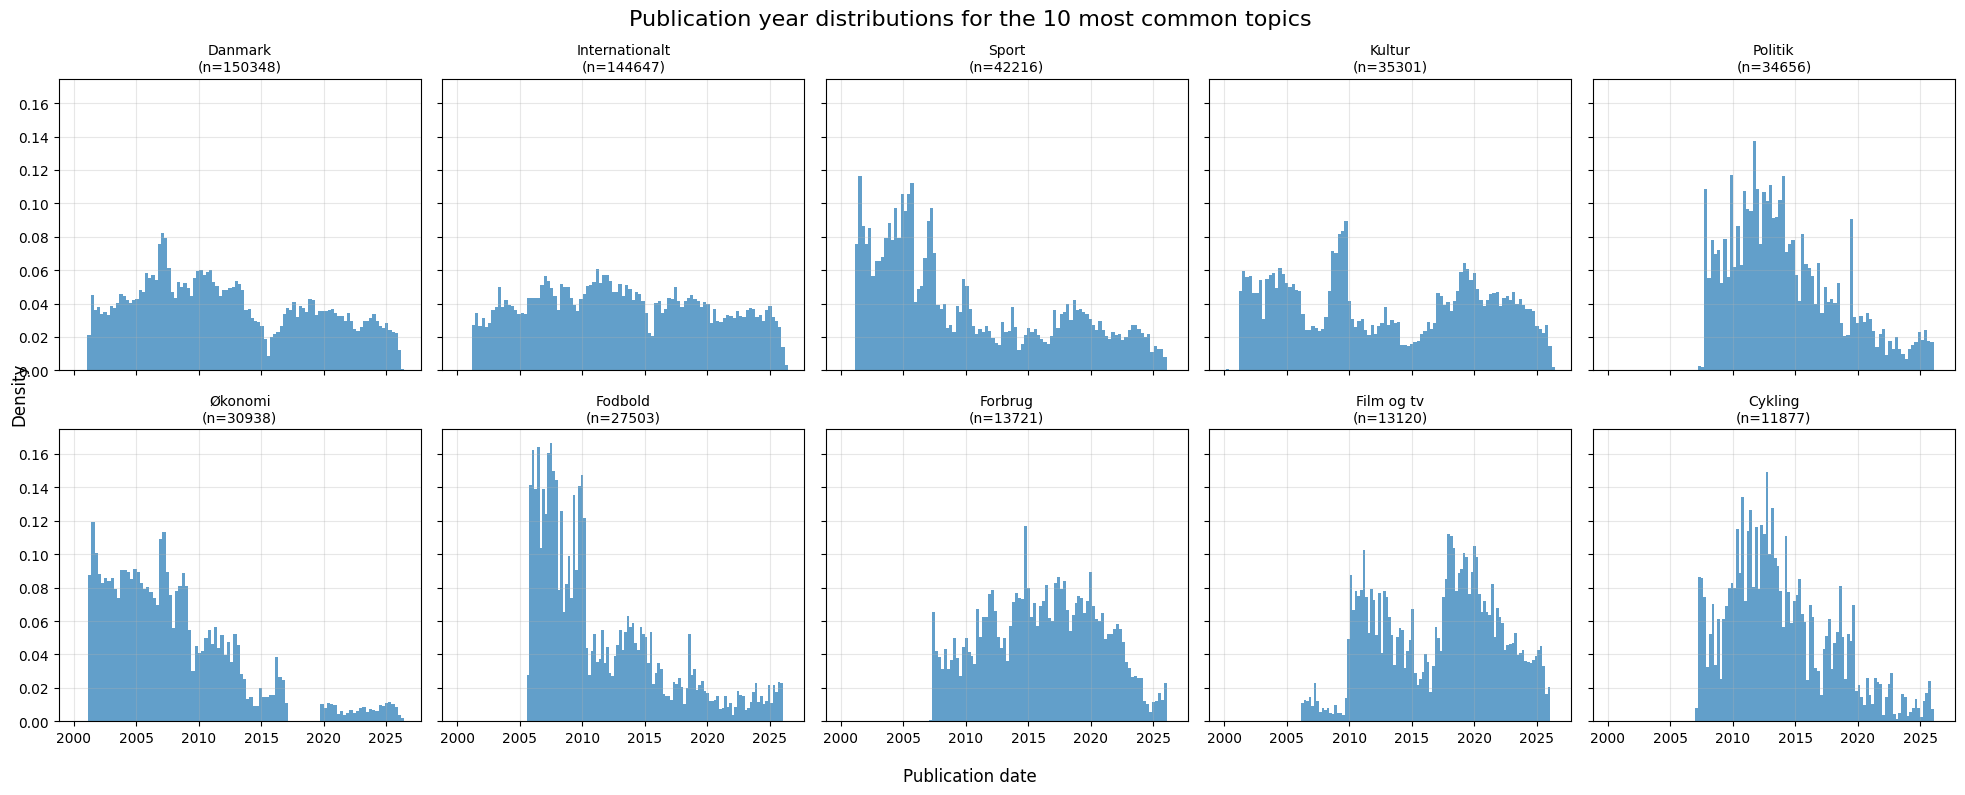

In [24]:
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

years = labels_articles_all[:, 0].astype(float)
topics = labels_articles_all[:, 3]

# Find 10 most common topics
top10 = Counter(topics).most_common(10)

fig, axes = plt.subplots(
    2, 5,
    figsize=(20, 8),
    sharex=True,
    sharey=True
)

axes = axes.ravel()

for ax, (topic, count) in zip(axes, top10):

    mask = topics == topic

    ax.hist(
        years[mask],
        bins=100,
        density=True,
        alpha=0.7
    )

    ax.set_title(
        f"{topic}\n(n={count})",
        fontsize=10
    )

    ax.grid(alpha=0.3)

# Common labels
fig.supxlabel("Publication date")
fig.supylabel("Density")
fig.suptitle(
    "Publication year distributions for the 10 most common topics",
    fontsize=16
)

plt.tight_layout()
plt.show()

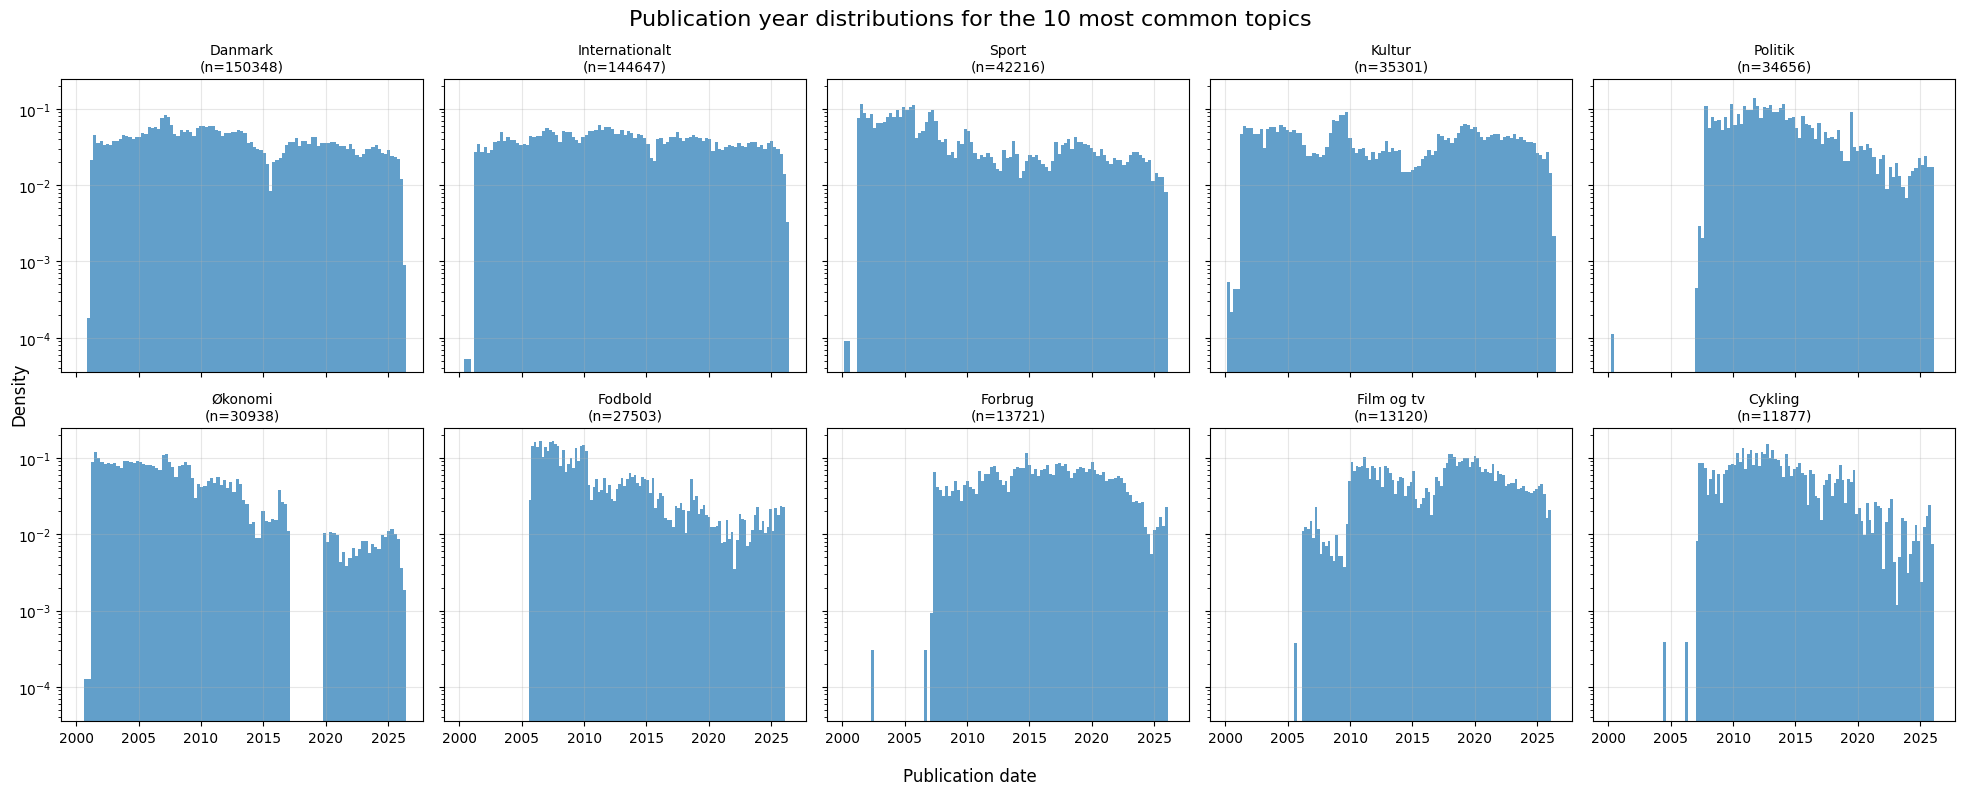

In [26]:
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

years = labels_articles_all[:, 0].astype(float)
topics = labels_articles_all[:, 3]

# Find 10 most common topics
top10 = Counter(topics).most_common(10)

fig, axes = plt.subplots(
    2, 5,
    figsize=(20, 8),
    sharex=True,
    sharey=True
)

axes = axes.ravel()

for ax, (topic, count) in zip(axes, top10):

    mask = topics == topic

    ax.hist(
        years[mask],
        bins=100,
        density=True,
        alpha=0.7
    )

    ax.set_title(
        f"{topic}\n(n={count})",
        fontsize=10
    )

    ax.grid(alpha=0.3)

ax.set_yscale("log")

# Common labels
fig.supxlabel("Publication date")
fig.supylabel("Density")
fig.suptitle(
    "Publication year distributions for the 10 most common topics",
    fontsize=16
)

plt.tight_layout()
plt.show()